In [1]:
import sqlite3
import pandas as pd

# Create database and connect
conn = sqlite3.connect('company.db')
cursor = conn.cursor()

# Create tables
cursor.executescript('''
CREATE TABLE IF NOT EXISTS employees (
    emp_id INTEGER PRIMARY KEY,
    name TEXT,
    department TEXT,
    salary INTEGER,
    joining_date TEXT
);

CREATE TABLE IF NOT EXISTS sales (
    sale_id INTEGER PRIMARY KEY,
    emp_id INTEGER,
    amount INTEGER,
    sale_date TEXT,
    region TEXT
);
''')

conn.commit()
print("Database created successfully")

Database created successfully


In [2]:
# Insert employee data
cursor.executemany('''
INSERT OR IGNORE INTO employees VALUES (?,?,?,?,?)
''', [
    (1, 'Amit Sharma', 'Sales', 55000, '2021-03-15'),
    (2, 'Priya Mehta', 'Marketing', 62000, '2020-07-01'),
    (3, 'Rahul Verma', 'Sales', 48000, '2022-01-10'),
    (4, 'Sneha Iyer', 'HR', 45000, '2021-11-20'),
    (5, 'Karan Patel', 'Marketing', 70000, '2019-05-30'),
    (6, 'Divya Nair', 'Sales', 52000, '2022-06-15'),
    (7, 'Rohit Das', 'HR', 47000, '2020-09-01'),
    (8, 'Ananya Roy', 'Tech', 85000, '2019-01-15'),
    (9, 'Vikram Singh', 'Tech', 92000, '2018-11-01'),
    (10, 'Pooja Joshi', 'Marketing', 58000, '2021-08-20')
])

# Insert sales data
cursor.executemany('''
INSERT OR IGNORE INTO sales VALUES (?,?,?,?,?)
''', [
    (1, 1, 15000, '2024-01-10', 'North'),
    (2, 3, 22000, '2024-01-15', 'South'),
    (3, 6, 18000, '2024-01-20', 'West'),
    (4, 1, 25000, '2024-02-05', 'North'),
    (5, 3, 12000, '2024-02-10', 'South'),
    (6, 6, 30000, '2024-02-18', 'West'),
    (7, 1, 20000, '2024-03-01', 'North'),
    (8, 3, 17000, '2024-03-12', 'East'),
    (9, 6, 22000, '2024-03-20', 'West'),
    (10, 2, 9000, '2024-03-25', 'East')
])

conn.commit()
print("Data inserted successfully")
print("Employees:", cursor.execute("SELECT COUNT(*) FROM employees").fetchone()[0])
print("Sales records:", cursor.execute("SELECT COUNT(*) FROM sales").fetchone()[0])

Data inserted successfully
Employees: 10
Sales records: 10


In [3]:
# Q1: View all employees
q1 = pd.read_sql("SELECT * FROM employees", conn)
print("=== All Employees ===")
print(q1)

# Q2: Average salary by department
q2 = pd.read_sql("""
    SELECT department, 
           AVG(salary) as avg_salary,
           COUNT(*) as headcount
    FROM employees
    GROUP BY department
    ORDER BY avg_salary DESC
""", conn)
print("\n=== Salary by Department ===")
print(q2)

# Q3: Top performing employees by sales
q3 = pd.read_sql("""
    SELECT e.name, e.department, SUM(s.amount) as total_sales
    FROM sales s
    JOIN employees e ON s.emp_id = e.emp_id
    GROUP BY e.name
    ORDER BY total_sales DESC
""", conn)
print("\n=== Top Performers ===")
print(q3)

=== All Employees ===
   emp_id          name department  salary joining_date
0       1   Amit Sharma      Sales   55000   2021-03-15
1       2   Priya Mehta  Marketing   62000   2020-07-01
2       3   Rahul Verma      Sales   48000   2022-01-10
3       4    Sneha Iyer         HR   45000   2021-11-20
4       5   Karan Patel  Marketing   70000   2019-05-30
5       6    Divya Nair      Sales   52000   2022-06-15
6       7     Rohit Das         HR   47000   2020-09-01
7       8    Ananya Roy       Tech   85000   2019-01-15
8       9  Vikram Singh       Tech   92000   2018-11-01
9      10   Pooja Joshi  Marketing   58000   2021-08-20

=== Salary by Department ===
  department    avg_salary  headcount
0       Tech  88500.000000          2
1  Marketing  63333.333333          3
2      Sales  51666.666667          3
3         HR  46000.000000          2

=== Top Performers ===
          name department  total_sales
0   Divya Nair      Sales        70000
1  Amit Sharma      Sales        60000
2

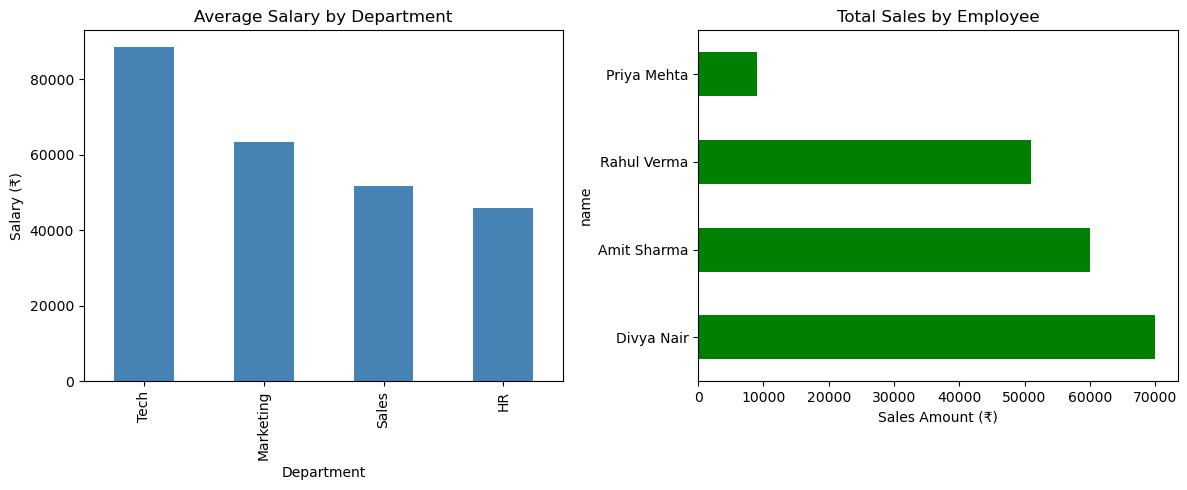

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1: Avg salary by department
q2.plot(kind='bar', x='department', y='avg_salary', 
        ax=axes[0], color='steelblue', legend=False)
axes[0].set_title('Average Salary by Department')
axes[0].set_ylabel('Salary (₹)')
axes[0].set_xlabel('Department')

# Chart 2: Total sales by employee
q3.plot(kind='barh', x='name', y='total_sales',
        ax=axes[1], color='green', legend=False)
axes[1].set_title('Total Sales by Employee')
axes[1].set_xlabel('Sales Amount (₹)')

plt.tight_layout()
plt.show()